In [5]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


X_full, y_full = make_moons(n_samples=1000, noise=0.1) 
X_train, X_test_valid, y_train, y_test_valid = train_test_split(X_full, y_full, test_size=0.3, random_state=39)
X_test, X_valid, y_test, y_valid = train_test_split(X_test_valid, y_test_valid, test_size=0.5, random_state=39)


model = DecisionTreeClassifier(random_state=39)


parameter_grid = {
  "max_leaf_nodes" : [2,3,4,5],
  "max_depth" : [2,3,4,5],
}

grid_search = GridSearchCV(model, param_grid=parameter_grid, cv=5, return_train_score=True, refit=True)

grid_search.fit(X_train, y_train)
model.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,39
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
score = grid_search.score(X_test, y_test)
print("Score: {:.2f}".format(score))
print(grid_search.best_estimator_)

Score: 0.93
DecisionTreeClassifier(max_depth=2, max_leaf_nodes=4, random_state=39)


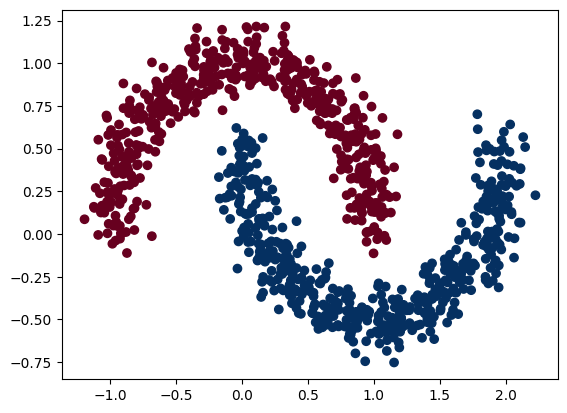

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X_full[:, 0], X_full[:, 1], c=y_full, cmap=plt.cm.RdBu)

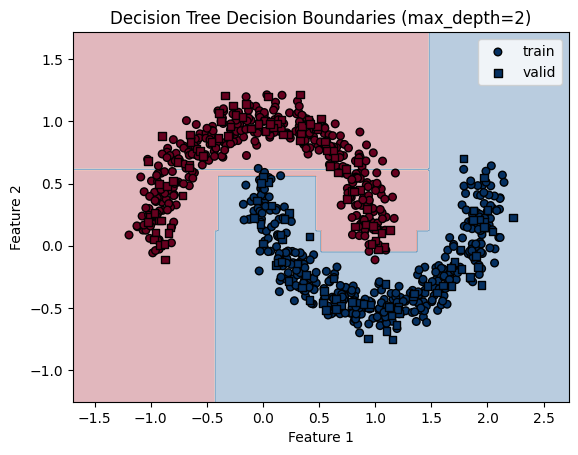

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# grid for plotting
x_min, x_max = X_full[:, 0].min() - 0.5, X_full[:, 0].max() + 0.5
y_min, y_max = X_full[:, 1].min() - 0.5, X_full[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# plot training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.RdBu, s=30, label="train")
plt.scatter(X_valid[:, 0], X_valid[:, 1], c=y_valid, edgecolor="k", cmap=plt.cm.RdBu, s=30, marker="s", label="valid")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Decision Boundaries (max_depth=2)")
plt.legend()
plt.show()
